<a href="https://colab.research.google.com/github/y250021-hitscope/HitAndBlowAnalyzer/blob/master/E02/mva_2026_E02_02_multiple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# mva_2026_E02_02_multiple_linear_regression.ipynb 線形重回帰モデル with scikit-learn
- 学籍番号 [y250021]
- 氏名 [志賀 楽夢]

課題2の解答をここに記入して．
- 切片 $\beta_0= 160.4933$
- weight の係数 $\beta_1= 9.6072$
- transparency の係数 $\beta_2= 2.9844$

In [1]:
import numpy as np # 数値計算ライブラリ
import pandas as pd # データ解析ライブラリ
import matplotlib.pyplot as plt # グラフ描画ライブラリ
%matplotlib inline

from sklearn.linear_model import LinearRegression # scikit-learn の線形重回帰ライブラリ

!pip install japanize_matplotlib
import japanize_matplotlib # 日本語フォント

from mpl_toolkits.mplot3d import Axes3D # 3Dプロット用のインポート
import plotly.graph_objects as go # 3次元インタラクティブプロット

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 35.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120306 sha256=5462d1377a691d20ae94efdcb394e67d669f614d61dd6b0db4ef27f0f1f5903d
  Stored in directory: /root/.cache/pip/wheels/56/8b/41/7c8a47025c6eef46f0b7488f2510fff13e48f1e7d5bf26e21b
Successfully built japanize_matplotlib


## 例：成績データ

### データの取得と整形

In [2]:
#   「Pythonで理解する統計解析の基礎」 谷合廣紀，辻 真吾，技術評論社，2018. のデータを，dataframe形式で読み込み
df=pd.read_csv("https://github.com/ghmagazine/python_stat_sample/raw/master/data/ch12_scores_reg.csv")
df

,小テスト,期末テスト,睡眠時間,通学方法
0,4.2,67,7.2,バス
1,7.2,71,7.9,自転車
2,0.0,19,5.3,バス
3,3.0,35,6.8,徒歩
4,1.5,35,7.5,徒歩
5,0.9,40,7.6,バス
6,1.9,23,4.3,徒歩
7,3.5,37,4.2,自転車
8,4.0,39,4.7,自転車
9,5.4,55,7.5,徒歩


- 統計モデルとして，線形重回帰 LinearRegression を採用
- Pythonライブラリとして，sklearn=scikit-learnを採用
  - 使い方や，結果の意味は全てここに書いてある
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [3]:
model=LinearRegression() # 上でfrom sklearn.linear_model import LinearRegression しているのでこれで使える

期末テストを目的変数$y$, 小テストを説明変数$x_1$, 睡眠時間を説明変数$x_2$ とする．行列Xとベクトルyを作る．

sklearn のLinearRegressionは，行列$X$に関して，1の列の追加や，中心化を自動的にやってくれるので，このdf相当のデータ
$$
  \begin{pmatrix}
    {x}_{11}&\quad {x}_{{1}{2}}\\
    \vdots & \vdots \\
    \vdots & \vdots \\    
    {x}_{{n}{1}}&\quad {x}_{{n}{2}}\\
  \end{pmatrix}
$$

をそのまま渡せばよい．

授業でやったこの形に整形しなくてよい.
$$
  X=
  \begin{pmatrix}
    1 & {x}_{11}-\overline{x}_{{\bullet}{1}}&\quad {x}_{{1}{2}}-{\overline{x}}_{{\bullet}{2}}\\
    \vdots & \vdots \\
    \vdots & \vdots \\    
    1 & {x}_{{n}{1}}-\overline{x}_{{\bullet}{1}}&\quad {x}_{{n}{2}}-\overline{x}_{{\bullet}{2}}\\
  \end{pmatrix}
$$


In [4]:
X_train=df.drop(["期末テスト", "通学方法"],axis=1) # 列を削除した dataframe
X_train_np = X_train.to_numpy() # NumPyの行列=2次元配列に変換
X_train_np

array([[4.2, 7.2],
       [7.2, 7.9],
       [0. , 5.3],
       [3. , 6.8],
       [1.5, 7.5],
       [0.9, 7.6],
       [1.9, 4.3],
       [3.5, 4.2],
       [4. , 4.7],
       [5.4, 7.5],
       [4.2, 4.4],
       [6.9, 5.7],
       [2. , 7.8],
       [8.8, 6.1],
       [0.3, 6.8],
       [6.7, 5.3],
       [4.2, 6.7],
       [5.6, 7.3],
       [1.4, 4.1],
       [2. , 7. ]])

yはdfから1列だけ取り出せばよい．これは，dfのSeriesと呼ばれる形．NumPy配列に変換すると1次元配列になる

In [5]:
y_train=df["期末テスト"] # 1列だけ取り出した Series
y_train_np = y_train.to_numpy() # numpyの1次元配列に変換

実は，`.to_numpy()`しなくても，`LinearRegression`が自動的に変換してくれるのだが，ここではやっておいた．

_train は，母数の推定に使う学習データ，訓練データ，教師データのこと．

$X$は特徴量，$y$はターゲットと呼ばれたりもする．

In [6]:
# 変換後のデータ型と形状（shape）を確認します
print("X_train_np の型:", type(X_train_np))
print("X_train_np の shape:", X_train_np.shape)
print("y_train_np の型:", type(y_train_np))
print("y_train_np の shape:", y_train_np.shape)

X_train_np の型: <class 'numpy.ndarray'>
X_train_np の shape: (20, 2)
y_train_np の型: <class 'numpy.ndarray'>
y_train_np の shape: (20,)


### 母数の推定：偏回帰係数と切片

In [7]:
# モデルの学習
model.fit(X_train_np, y_train_np) # 固定順序の引数
# 結果は，返り値でなく，modelのpropertyとして保存される．

LinearRegression()

In [8]:
# 偏回帰係数と切片、決定係数を取得して表示
print("説明変数:", X_train.columns.tolist())
print("偏回帰係数β1,β2:", model.coef_)
print("切片β0:", model.intercept_)
print("決定係数 (R^2):", model.score(X_train, y_train))

説明変数: ['小テスト', '睡眠時間']
偏回帰係数β1,β2: [6.42887834 4.19170655]
切片β0: -1.8709143470995926
決定係数 (R^2): 0.7560835046445387


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


### 予測

xのデータを与えて，その値に対してyを計算させる．

In [9]:
model.predict(np.array([[2,3]]))

array([23.56196198])

そもそも母数の推定に使ったxのデータに対して予測させる

In [10]:
model.predict(X_train_np)

array([55.31066183, 77.53149144, 20.34513035, 45.9193252 , 39.21020227,
       35.77204591, 28.36829265, 38.23532735, 43.54561979, 64.2828278 ,
       43.5738835 , 66.38107353, 43.6821534 , 80.272625  , 28.56135367,
       63.41861525, 53.21480855, 64.73026216, 24.31551217, 40.32878816])

### 可視化
このセクションの中身は理解せず実行すればよい

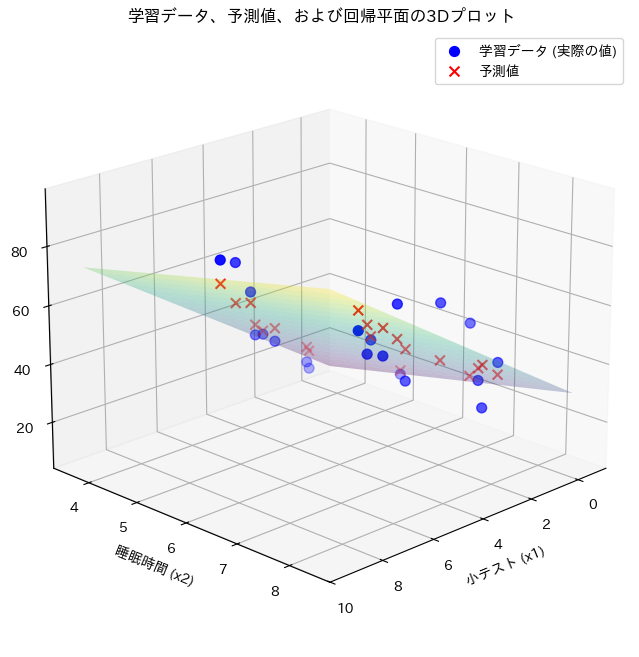

In [11]:
# データの準備
x1 = X_train_np[:, 0] # 小テスト
x2 = X_train_np[:, 1] # 睡眠時間
y = y_train_np        # 期末テスト

# 予測値の計算
y_pred = model.predict(X_train_np)

# 回帰平面を描画するためのグリッドデータを作成
x1_range = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 20)
x2_range = np.linspace(x2.min() - 0.5, x2.max() + 0.5, 20)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

# 各グリッドポイントでの予測値を計算 (Z軸の値)
# 予測式: y = b0 + b1*x1 + b2*x2
Y_grid = model.intercept_ + model.coef_[0] * X1_grid + model.coef_[1] * X2_grid

# グラフの描画設定
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 実際の学習データを散布図としてプロット
ax.scatter(x1, x2, y, color='blue', s=50, label='学習データ (実際の値)')

# 予測値を散布図としてプロット
ax.scatter(x1, x2, y_pred, color='red', s=50, marker='x', label='予測値')

# 回帰平面をプロット
ax.plot_surface(X1_grid, X2_grid, Y_grid, alpha=0.3, cmap='viridis')

# 視点の設定 (elev: 上下の角度, azim: 左右の回転角度)
# この値を調整することで見え方が変わります
ax.view_init(elev=20, azim=45)

# ラベルとタイトルの設定
ax.set_xlabel('小テスト (x1)')
ax.set_ylabel('睡眠時間 (x2)')
ax.set_zlabel('期末テスト (y)')
ax.set_title('学習データ、予測値、および回帰平面の3Dプロット')
ax.legend()

plt.show()

マウスでドラッグして視点を変えられる可視化

In [12]:
# データの準備
x1 = X_train_np[:, 0] # 小テスト
x2 = X_train_np[:, 1] # 睡眠時間
y = y_train_np        # 期末テスト

# 予測値の計算
y_pred = model.predict(X_train_np)

# 回帰平面を描画するためのグリッドデータを作成
x1_range = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 20)
x2_range = np.linspace(x2.min() - 0.5, x2.max() + 0.5, 20)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

# 各グリッドポイントでの予測値を計算
Y_grid = model.intercept_ + model.coef_[0] * X1_grid + model.coef_[1] * X2_grid

# Plotly フィギュアの作成
fig = go.Figure()

# 1. 実際の学習データを散布図として追加
fig.add_trace(go.Scatter3d(
    x=x1,
    y=x2,
    z=y,
    mode='markers',
    marker=dict(size=6, color='blue', opacity=0.8),
    name='学習データ (実際の値)'
))

# 2. 予測値を散布図として追加
fig.add_trace(go.Scatter3d(
    x=x1,
    y=x2,
    z=y_pred,
    mode='markers',
    marker=dict(size=6, color='red', symbol='x', opacity=0.8),
    name='予測値'
))

# 3. 回帰平面を追加
fig.add_trace(go.Surface(
    x=X1_grid,
    y=X2_grid,
    z=Y_grid,
    opacity=0.5,
    colorscale='Viridis',
    showscale=False,
    name='回帰平面'
))

# レイアウトの設定
fig.update_layout(
    title='学習データ、予測値、および回帰平面の3Dインタラクティブプロット',
    scene=dict(
        xaxis_title='小テスト (x1)',
        yaxis_title='睡眠時間 (x2)',
        zaxis_title='期末テスト (y)'
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    width=800,
    height=600
)

fig.show()

## 課題1:その場で与えたデータ

チーム課題 teamL02 のデータを，下のように値をてコピーして入力して，偏回帰係数を求めるところまでやろう

In [18]:
X2_train_np=np.array([[0,0],[0,2],[8,0],[4,6]])
y2_train_np=np.array([2,4,6,8])

In [19]:
model2 = LinearRegression()
model2.fit(X2_train_np, y2_train_np)

print("偏回帰係数β1,β2:", model2.coef_)
print("切片β0:", model2.intercept_)
print("決定係数 (R^2):", model2.score(X2_train_np, y2_train_np))

偏回帰係数β1,β2: [0.45454545 0.66666667]
切片β0: 2.303030303030302
決定係数 (R^2): 0.9878787878787879


## 課題2:個人別課題データ

個人別に，MoodleのE02_02出題用からダウンロードしたCSVデータを，E00_04を参照して左側のフォルダ内にアップロードし，偏回帰係数を求めるところまでやろう．結果はこのNotebookの最初に書こう．

In [20]:
df3 = pd.read_csv("data.csv")
df3

,weight,transparency,price
0,11,83,513
1,20,58,522
2,20,96,640
3,17,57,499
4,18,62,517
5,12,83,524
6,10,74,475
7,12,72,493
8,10,80,495


In [21]:
# 目的変数に評価項目(あるいは目的の列)を設定、説明変数に weight と transparency を設定します
# データの中身の列名に合わせて適宜修正を加えてください
print("データの列名一覧:", df3.columns.tolist())

# 例：説明変数 X3 と 目的変数 y3 の定義
# （実際の列名が異なる場合は、この部分の列名を適切なものに変更してください）
X3_train = df3[['weight', 'transparency']]
y3_train = df3.iloc[:, -1] # 一番最後の列などを目的変数と仮定

model3 = LinearRegression()
model3.fit(X3_train, y3_train)

print("--- 課題2 結果 ---")
print("偏回帰係数(weight, transparency):", model3.coef_)
print("切片β0:", model3.intercept_)
print("決定係数 (R^2):", model3.score(X3_train, y3_train))

データの列名一覧: ['weight', 'transparency', 'price']
--- 課題2 結果 ---
偏回帰係数(weight, transparency): [9.60716213 2.98440457]
切片β0: 160.49332060369716
決定係数 (R^2): 0.996995667975303
